# Data preprocessing

We are going to start Preprocessing the data from the "liar" dataset in order to make it ready for the model, while following the README.md file.

Below we will import all required modules for this notebook:

In [1]:
import pandas as pd

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_validate, train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_predict

from xgboost import XGBClassifier

import numpy as np
import matplotlib.pyplot as plt

from rapidfuzz import process

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Importing Liar Data (TEST + TRAIN + VAL together)

In [3]:
# In the "liar" dataset, we know the columns are ordered as follows:
columns = [
    'id',
    'label',
    'statement',
    'subject',
    'speaker',
    'job_title',
    'state',
    'party',
    'barely_true_counts',
    'false_counts',
    'half_true_counts',
    'mostly_true_counts',
    'pants_on_fire_counts',
    'context'
]

df_l_train = pd.DataFrame(pd.read_csv('/home/mnavarrosotes/code/navaso93/final_project/liar_project/raw_data/liar/train.tsv', sep='\t', header=None, names=columns))
df_l_test = pd.DataFrame(pd.read_csv('/home/mnavarrosotes/code/navaso93/final_project/liar_project/raw_data/liar/test.tsv', sep='\t', header=None, names=columns))
df_l_val = pd.DataFrame(pd.read_csv('/home/mnavarrosotes/code/navaso93/final_project/liar_project/raw_data/liar/valid.tsv', sep='\t', header=None, names=columns))

print("Shape of TRAIN dataset is: ", df_l_train.shape)
print("Shape of TEST dataset is: ", df_l_test.shape)
print("Shape of validation dataset is: ", df_l_val.shape)

df_l_tt = pd.concat([df_l_train, df_l_test], ignore_index=True)
df_l = pd.concat([df_l_tt, df_l_val], ignore_index=True)

print("Shape of merged dataset is: ", df_l.shape)
df_l.head()

Shape of TRAIN dataset is:  (10240, 14)
Shape of TEST dataset is:  (1267, 14)
Shape of validation dataset is:  (1284, 14)
Shape of merged dataset is:  (12791, 14)


,id,label,statement,subject,speaker,job_title,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


### Importing Politifact data

In [4]:
# Reading JSON file considering trailing lines
df_pol = pd.read_json("/home/mnavarrosotes/code/navaso93/final_project/liar_project/raw_data/politifact/politifact_factcheck_data.json", lines=True)

# Replacing different label values to match those of LIAR dataset
df_pol["verdict"] = df_pol["verdict"].replace({'mostly-false': 'barely-true'})

# Renaming columsn to match those names in LIAR dataset
df_pol = df_pol.rename(columns={'verdict':'label','statement_originator':'speaker', 'statement_source':'context'})
df_pol = df_pol[["label", "speaker","statement","context"]]


### Concatenating Politifact + LIAR data

In [5]:
df_dataset = pd.concat([df_l, df_pol], axis=0, ignore_index=True)

# What if we only preserve certain data:
df_dataset = df_dataset[["label", "speaker","statement","context"]]

## Text Preprocessing

As mentionned in the README.md file, we will apply the following sequence to all text features:
- **strip:** Removes all whitespaces at the beginning anfd the end of a string. You can also specify a list of characters to be removed at the beginning and end of a string (RECOMMENDED)
- **replace:** Can be used to replace some words by another.
- **split:** Used to split a text into a lsit, where each word is an item.
- **numbers:** Numbers should be removed during text preprocessing steps.
- **punctuation and symbols:** Punctuation and other symbols should be removed for text preprocessing.

In [6]:
def df_text_preprocessing(df):
    """
    Reformats all text in the dataset.
    Concatenates speaker and statement column, so we end up having "speaker + statement".
    This prevents us having to encode speaker later, while still getting its information.
    """

    # We remove "id" column
    if "id" in df.columns:
        df = df.drop(columns="id")

    # We define columns
    text_col = [
        'statement',
        'subject',
        'speaker',
        'job_title',
        'state',
        'party',
        'context'
    ]

    # Iterate through each column applying text preprocessing methods
    for col in text_col:
        if col in df.columns:
            df[col] = (
                df[col]
                .fillna("")
                .astype(str)
                .str.lower()
                .str.strip()
                .str.replace(r"\d+", "", regex=True) # We replace numbers by empty values
                .str.replace(r"[^\w\s]", " ", regex=True) # We replace punctuation by blank spaces, since it might separate two words.
            )

    # We concatenate the strings in "speaker" and "statement"
    df["statement"] = df["speaker"] + " " +  df["statement"]

    # We drop the "speaker" column as it is reduncdant now
    df = df.drop(columns="speaker")


    return df


### Specific column fixes

#### State

Some state names are differently typed for the same state (we have 84 different states!!!), or have other issues that cause the model to loose context. We should cluster the state names only into the valid names:

In [7]:
# Function that finds the closest valid state name
def correct_state(state):

    valid_states = [
        "alabama", "alaska", "arizona", "arkansas", "california", "colorado", "connecticut", "delaware", "florida",
        "georgia", "hawaii", "idaho", "illinois", "indiana", "iowa", "kansas", "kentucky",
        "louisiana", "maine", "maryland", "massachusetts", "michigan", "minnesota", "mississippi", "missouri",
        "montana", "nebraska", "nevada", "new hampshire", "new jersey",
        "new mexico", "new york", "north carolina", "north dakota", "ohio",
        "oklahoma", "oregon", "pennsylvania", "rhode island", "south carolina",
        "south dakota", "tennessee", "texas", "utah", "vermont",
        "virginia", "washington", "west virginia", "wisconsin", "wyoming"
    ]
    # Handle missing values
    if pd.isna(state):
        return "unknown"

    # Convert to lowercase and remove spaces around the test
    state = str(state).lower().strip()

    # Find the closest match from the valid states list
    match, score, _ = process.extractOne(state, valid_states)

    # Only replace if similarity is high enough
    # We will be flexible and apply a similarity threshold of 75%
    if score >= 80:
        return match

    # Otherwise keep original value
    return state

#### Job Title

The values in the Job Title column are too scattered and non uniform. This prevents the model from gaining important context for the predictions.
We are going to try and cluster all the values into a smaller group:

In [8]:
def simplify_job_title(title):

    if pd.isna(title):
        return "unknown"

    if title in ["president", "president elect", "presidential candidate", "former president"]:
        return "president"

    elif "governor" in title:
        return "governor"

    elif "senator" in title:
        return "senator"

    elif "legislator" in title:
        return "legislator"

    elif 'mayor' in title:
        return 'mayor'

    elif 'ambassador' in title:
        return 'ambassador'

    elif any(x in title for x in ["representative", "congressman", "congresswoman", "house"]):
        return "representative"

    elif "attorney" in title or "lawyer" in title:
        return "legal"

    elif any(x in title for x in ["radio host", "host", "journalist", "reporter", "blog", 'social', 'columnist']):
        return "media"

    elif any(x in title for x in ['president', 'ceo', 'director', 'founder', 'business']):
        return 'private executive'

    elif "candidate" in title:
        return "candidate"

    else:
        return "other"

#### Context

In [9]:
# Function to simplify context values into broader categories
def simplify_context(context):

    # Handle missing values
    if pd.isna(context):
        return "unknown"

    # Convert to Lowercase for consistent matching
    context = str(context).lower()

    # Ads and commercials
    if any(x in context for x in ["ad", "commercial", "mailer"]):
        return "ad"

    # Interviews
    elif "interview" in context:
        return "interview"

    # Speeches and remarks
    elif any(x in context for x in ["press release", "news release"]):
        return "press release"

    # Press and news conferences
    elif any(x in context for x in ["press conference", "news conference"]):
        return "news conference"

    # Debates
    elif "debate" in context:
        return "debate"

    # Social media and websites
    elif any(x in context for x in ["tweet", "facebook", "website", "social"]):
        return "social media"

    # Statements
    elif "statement" in context:
        return "statement"

    # Emails
    elif any(x in context for x in ["email", " e mail", "chain mail"]):
        return "email"

    # TV appearances
    elif any(x in context for x in ["television", "tv", "fox news", "cnn", "meet the press"]):
        return "tv appearance"

    # Everything else
    else:
        return "other"

#### Party

In [10]:
# Function to simplify party affiliations into 5 broad categories
def simplify_party(party):

    # Handle missing values
    if pd.isna(party):
        return "unknown"

    # Convert to lowercase for consistent matching
    party = str(party).lower()

    # Republicans and related groups
    if any(x in party for x in ["republican", "tea party"]):
        return "republican"

    # Democrats and related groups
    elif any(x in party for x in ["democrat", "democratic farmer labor"]):
        return "democrat"

    # Other political parties
    elif any(x in party for x in ["independent", "libertarian", "green", "constitution party", "moderate"]):
        return "other_party"

    # Non-party entities, professions and organizations
    elif any(x in party for x in ["organization", "journalist", "columnist", "newsmaker", "activist", "talk show host", "state official", "education official",
        "government body", "business leader", "labor leader", "commissioner"]):
        return "organization"

    # Missing or unknown affiliation
    elif party == "none":
        return "unknown"

    # Catch any remaining rare values
    else:
        return "other"

#### Subject

There are initially 4144 different subjects. This is an excessively high number, especially considering that lots of them are the same, but written diffrently. We will try to cluster the main categories to avoid repetition under different wording.

In [11]:
# Function to simplify subjects into broader topic groups
def simplify_subject(subject):

    # Handle missing values
    if pd.isna(subject):
        return "unknown"

    # Convert to lowercase for consistent matching
    subject = str(subject).lower()

    # Health
    if any(x in subject for x in ["health", "medicare", "medicaid", "hospital", "disease", "ebola"]):
        return "health"

    # Economy and jobs
    elif any(x in subject for x in ["economy", "job", "worker", "small business", "income"]):
        return "economy"

    # Taxation
    elif "tax" in subject:
        return "taxation"

    # Budget and finance
    elif any(x in subject for x in ["budget", "finance", "deficit", "debt"]):
        return "budget"

    # Education
    elif "education" in subject:
        return "education"

    # Immigration
    elif any(x in subject for x in ["immigration", "border", "refugee"]):
        return "immigration"

    # Elections and campaigns
    elif any(x in subject for x in ["election", "candidate biography", "campaign", "voting record"]):
        return "elections"

    # Security and crime
    elif any(x in subject for x in ["crime", "criminal justice", "terrorism", "gun", "public safety"]):
        return "security"

    # Foreign affairs
    elif any(x in subject for x in ["foreign policy", "iraq", "afghanistan", "china", "israel", "trade"]):
        return "foreign affairs"

    # Environment and climate
    elif any(x in subject for x in ["environment", "climate", "weather"]):
        return "environment"

    # Energy
    elif "energy" in subject:
        return "energy"

    # Transportation
    elif "transportation" in subject:
        return "transportation"

    # Military and veterans
    elif any(x in subject for x in ["military", "veteran", "defense"]):
        return "military"

    # Government and politics
    elif any(x in subject for x in ["government", "ethic", "legal issue", "congress"]):
        return "government"

    # Social issues
    elif any(x in subject for x in ["abortion", "religion", "gay", "lesbian", "woman", "queer", "marriage"]):
        return "social issues"

    # Science and technology
    elif any(x in subject for x in ["science", "technology", "research"]):
        return "science"

    # Everything else
    else:
        return "other"

#### Label

The label ahs currently 6 categories,a nd for the model to properly distinguish between e.g. a "partly-true" statement and a "mostly-true" statement, it can be hard (it is even for humans!). 
We will cluster the label into 3 categories:

In [12]:
def simplify_label(label):

    # Already simplified -> leave unchanged
    if label in ["trustworthy", "questionable", "unreliable"]:
        return label

    if label in ["true", "mostly-true"]:
        return "trustworthy"

    elif label == "half-true":
        return "questionable"

    else:
        return "unreliable"

#### Speaker truthfulness score

As there are some NaN values in the counter of statement truthfulness for each speaker, we will remove them and assume them as zero. This will allow us to later use the ColumnTransformer.

In [13]:
def fill_speaker_history(df):

    score_cols = [
        "barely_true_counts",
        "false_counts",
        "half_true_counts",
        "mostly_true_counts",
        "pants_on_fire_counts"
    ]
    for col in score_cols:
        if col in df.columns:
            df[score_cols] = df[score_cols].fillna(0)
    return df

### We apply ALL data preprocessing

In [14]:
def full_preprocessing(df):

    if "label" in df.columns:
        df["label"] = df["label"].apply(simplify_label) # First we cluster label categories

    df = df_text_preprocessing(df) # Then we apply all preprocessing methods

    if "state" in df.columns:
        df["state"] = df["state"].apply(correct_state) # We cluster state column as per function

    if "job_title" in df.columns:
        df["job_title"] = df["job_title"].apply(simplify_job_title) # We cluster job_title column as per function

    if "context" in df.columns:
        df["context"] = df["context"].apply(simplify_context) # We cluster context column as per function

    if "party" in df.columns:
        df["party"] = df["party"].apply(simplify_party) # We cluster party column as per function

    if "subject" in df.columns:
        df["subject"] = df["subject"].apply(simplify_subject) # We cluster subject column as per function

    df = fill_speaker_history(df) # We clean speaker history column form NaN and fill with 0

    return df


## Tokenizing

In [15]:
def tokenizer(df):

    # We define which columns we want to tokenize
    col_tk = ['statement',
              'subject',
              'job_title',
              'state',
              'context']

    for col in col_tk:
        if col in df.columns:
            df[col] = df[col].fillna("").apply(word_tokenize)

    return df

## Stopwords

In [16]:
def rm_stopwords(df):

    # Define list of stopwords
    stop_words = set(stopwords.words('english'))

    # Iterate through dataframe columns to remove stopwords
    col_tk = ['statement', 'subject', 'job_title', 'state', 'context']

    for col in col_tk:
        if col in df.columns:
            df[col] = df[col].apply(lambda tokens: [w for w in tokens if w not in stop_words])

    return df


## Lemmatize

In [17]:
def lemmatizer(df):

    # We instantiate lemmatizer and columns to lemmatize
    lemmatizer = WordNetLemmatizer()
    col_lm = ['statement', 'subject', 'job_title', 'state', 'context']

    # We lemmatize the columns
    for col in col_lm:
        if col in df.columns:
            df[col] = df[col].apply(lambda tokens: [WordNetLemmatizer().lemmatize(w) for w in tokens])

    return df

# Reformatting to string before Vectorizing

First, columns, need to be put back as a string, not a list.

In [18]:
def df_stringifier(df):

    # We define columns to vectorize
    col_vc = ['statement', 'subject', 'job_title', 'state', 'context']

    # We reformat tokenized columns back to strings (not lists) to prepare for vectorization
    for col in col_vc:
        if col in df.columns:
            df[col] = df[col].apply(lambda token: " ".join(token))

    return df

# Vectorizing + Testing model (Naive Bayes) 

### Train Test Split

In [19]:
def split_data(df):

    y = df["label"]
    X = df.drop(columns=["label"])

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    return X_train, X_test, y_train, y_test, y_train.value_counts(normalize=True)

In [20]:
def train_naive_bayes(X_train, y_train):
    # Initializing preprocessor
    preprocessor = ColumnTransformer(
        transformers = [
            ("statement", TfidfVectorizer(max_df=0.9, min_df=1, ngram_range=(1, 3)), "statement"),
            #("subject", OneHotEncoder(handle_unknown="ignore"), ["subject"]),
            ("context", OneHotEncoder(handle_unknown="ignore"), ["context"])#,
            #("job_title", OneHotEncoder(handle_unknown="ignore"), ["job_title"]),
            #("party", OneHotEncoder(handle_unknown="ignore"), ["party"]),
            #("state", OneHotEncoder(handle_unknown="ignore"), ["state"]),
            #("speaker_history", "passthrough", ["barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts"])
        ]
    )

    # Pipeline vectorizer + Naive Bayes
    pipeline_nb = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", MultinomialNB(alpha=0.1))]
    )

    # We will create probability of a statement being unreliable by using different folds in the dataset
    probas = cross_val_predict(
        pipeline_nb,
        X_train,
        y_train,
        cv=5,
        method="predict_proba", # Creates probabilities of each label to be correct
        n_jobs=-1
    )

    # Training model on all data
    pipeline_nb.fit(X_train, y_train)

    # We define unrel_proba (probability of statement being unreliable)
    unrel_proba = pd.DataFrame(
        probas[:, 2],
        columns=["unrel_proba"],
        index=X_train.index
    )

    return pipeline_nb, unrel_proba

In [21]:
def gridsearch_nb(pipeline_nb, df):

    X = df.drop(columns="label")
    y = df["label"]

    # Fine tuning with GridSearchCV
    # Train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.11, random_state=1)

    # Hyperparameter Grid
    grid = {
        "preprocessor__statement__ngram_range": [(1,1), (1,2)],
        "preprocessor__statement__min_df": [1, 5],
        "preprocessor__statement__max_df": [0.9, 0.95],
        "classifier__alpha": [0.1, 1, 10]
    }

    search_grid = GridSearchCV(
        pipeline_nb,
        grid,
        scoring= ['accuracy'], #{'recall': 'recall_macro', 'f1': 'f1_macro'},
        cv=5,
        n_jobs=-1, # parallelize computation,
        refit='accuracy'
    )

    search_grid.fit(X_train, y_train)

    print("Best params:" , search_grid.best_params_)
    print("Best scores: ", search_grid.best_score_)

    return search_grid.best_params_, search_grid.best_score_

In [22]:
#def gridsearch(pipeline_xgb, df):

# grid_xg = [
#     {
#         "classifier__n_estimators": [100, 300, 500],
#         "classifier__max_depth": [3, 6, 10],
#         "classifier__learning_rate": [0.01, 0.1, 0.3],
#         "classifier__subsample": [0.8, 1.0]
#     }
# ]

# search_grid_A_xg = GridSearchCV(
#     pipeline_A_xg,
#     grid_xg,
#     scoring= ['accuracy'], #{'recall': 'recall_macro', 'f1': 'f1_macro'},
#     cv=5,
#     n_jobs=-1, # parallelize computation,
#     refit='accuracy'
# )

# search_grid_A_xg.fit(X_A_train, y_A_train_e)

# print("SearchGrid best_score: ", search_grid_A_xg.best_score_)
# print("SearchGrid best_params: ", search_grid_A_xg.best_params_)

## On top of Naive Bayes we will use XGBoost
### After adding 'unrel_proba' as a feature

In [23]:
def train_xg_boost(X_train, y_train, unrel_proba):

    # Create features and target and 'statement' column to avoid redundancy with unrel_proba, as well as excessive computaitonal cost
    X_train_ns = X_train.drop(columns=["statement"])

    # Appending 'unrel_proba' to features table
    X_extended = pd.concat([X_train_ns, unrel_proba], axis=1)

    # Preprocessing all columns
    preprocessor_xgb = ColumnTransformer(
        transformers = [
            #("subject", OneHotEncoder(handle_unknown="ignore"), ["subject"]),
            ("context", OneHotEncoder(handle_unknown="ignore"), ["context"]),
            #("job_title", OneHotEncoder(handle_unknown="ignore"), ["job_title"]),
            #("party", OneHotEncoder(handle_unknown="ignore"), ["party"]),
            #("state", OneHotEncoder(handle_unknown="ignore"), ["state"]),
            #("speaker_history", "passthrough", ["barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts"]),
            ("unrel_proba", "passthrough", ["unrel_proba"])
        ]
    )

    # Instantiating pipeline
    pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor_xgb),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.3,
        subsample=0.1,
        colsample_bytree=0.8,
        random_state=42
        ))
    ])

    print("TYPES: ", X_extended.dtypes)
    print("X_extnded shape", X_extended.shape)

    # Applying label encoder for XGBoost
    le = LabelEncoder()
    y_e = le.fit_transform(y_train)
    print("y_e shape", y_e.shape)


    # Fitting pipeline with train data
    pipeline_xgb.fit(X_extended, y_e)

    return pipeline_xgb, le # Returns the trained pipeline_xgb to be used in another predict function AND the Label Encoder object

In [24]:
def liar_predict(pipeline_nb, pipeline_xgb, le, X_predict):

    # We handle NaN values in X_predict, since NB can not predict if there are NaN values
    # We map NaN values to same values the models were trained on: "unknown" and 0 for numerical columns

    # Possible columns and default values (if NaN) mapping
    possible_cols = ["statement","subject","speaker","job_title","state","party","context","false_counts","half_true_counts","barely_true_counts","pants_on_fire_counts","mostly_true_counts"]
    default_values = ["unknown", "unknown", "unknown", "unknown", "unknown", "unknown", "unknown", 0, 0, 0, 0, 0]
    X_actual = {}

    for c, v in zip(possible_cols, default_values):
        if c in X_predict.columns:
            X_actual[c] = v

    X_predict_n = X_predict.fillna(X_actual)

    # Before editing X_extended we predict with Naive Bayes for better overview
    pred_nb = pipeline_nb.predict(X_predict_n)
    probas_nb = pipeline_nb.predict_proba(X_predict_n)

    # Extract predicted probability of statement being unreliable, based on trained Naive Bayes model
    unrel_proba = pd.DataFrame(pipeline_nb.predict_proba(X_predict_n)[:, 2], columns=["unrel_proba"])

    # Append feature
    X_extended = pd.concat([X_predict_n, unrel_proba], axis=1)

    # Drop 'statement' from X_extended
    X_extended = X_extended.drop(columns="statement")

    pred_xgb_coded = pipeline_xgb.predict(X_extended)
    probas_xgb = pipeline_xgb.predict_proba(X_extended)

    # Decode labels
    pred_xgb = le.inverse_transform(pred_xgb_coded)

    return {
        "pred_nb": pred_nb,
        "probas_nb": probas_nb,
        "classes_nb": pipeline_nb.classes_,
        "pred_xgb": pred_xgb,
        "probas xgb": probas_xgb,
        "classes_xgb": le.inverse_transform(pipeline_xgb.classes_)
    }

In [25]:
def evaluate_nb(pipeline_nb, X_test, y_test):

    y_pred = pipeline_nb.predict(X_test)
    unrel_proba_test = pd.Series(
        pipeline_nb.predict_proba(X_test)[:, 2],
        index=X_test.index,
        name="unrel_proba"
    )

    results_dict = {
        "accuracy": accuracy_score(y_test, y_pred),
        "recall_macro": recall_score(y_test, y_pred, average="macro"),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "classification_report": classification_report(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "y_test": y_test,
        "y_pred": y_pred
    }

    return results_dict, unrel_proba_test

In [26]:
def evaluate_xgb(X_test, y_test, pipeline_xgb, le, unrel_proba):

    # print(X_train.index.equals(unrel_proba_train.index))
    X_extended = pd.concat([X_test, unrel_proba], axis=1)
    X_extended_ns = X_extended.drop(columns=["statement"])

    y_test_e = le.transform(y_test)

    y_pred_e = pipeline_xgb.predict(X_extended_ns)

    print("y_test_e:", y_test_e.shape)
    print("y_pred_e:", y_pred_e.shape)
    return {
        "accuracy": accuracy_score(y_test_e, y_pred_e),
        "recall_macro": recall_score(y_test_e, y_pred_e, average="macro"),
        "f1_macro": f1_score(y_test_e, y_pred_e, average="macro"),
        "classification_report": classification_report(y_test_e, y_pred_e),
        "confusion_matrix": confusion_matrix(y_test_e, y_pred_e),
        "y_test": y_test_e,
        "y_pred": y_pred_e
    }

In [27]:
df_preproc = full_preprocessing(df_dataset)
df_token = tokenizer(df_preproc)
df_sw = rm_stopwords(df_token)
df_lm = lemmatizer(df_sw)
df_st = df_stringifier(df_lm)

X_train, X_test, y_train, y_test, ycounts = split_data(df_st)
pipeline_nb, unrel_proba_train = train_naive_bayes(X_train, y_train)
pipeline_xgb, le = train_xg_boost(X_train, y_train, unrel_proba_train)
nb_results, unrel_proba_test = evaluate_nb(pipeline_nb, X_test, y_test)
xgb_results = evaluate_xgb(X_test, y_test, pipeline_xgb, le, unrel_proba_test)

print("NB Accuracy: ", nb_results["accuracy"])
print("XGB Accuracy: ", xgb_results["accuracy"])
print("NB recall: ", nb_results["recall_macro"])
print("XGB recall: ", nb_results["recall_macro"])
print("NB recall: ", nb_results["f1_macro"])
print("XGB recall: ", nb_results["f1_macro"])

TYPES:  context         object
unrel_proba    float64
dtype: object
X_extnded shape (27154, 2)
y_e shape (27154,)
y_test_e: (6789,)
y_pred_e: (6789,)
NB Accuracy:  0.856827220503756
XGB Accuracy:  0.730593607305936
NB recall:  0.8125035232462477
XGB recall:  0.8125035232462477
NB recall:  0.8371098674623881
XGB recall:  0.8371098674623881


In [33]:
X_predict = pd.DataFrame({
    "statement": [
        "Society likes good healthcare",
        "Clinton Says Paul Ryan is still endorsing Trump.",
        "Obama is not a man",
        "The sky is blue",
        "Donald Trump was born on Mars"
    ],
    "subject": ["Politics", "Social issues", "Politics", "Environment", "Politics"],
    "speaker": ["Donald Trump", "Hillary Clinton", "Blog", "Media", "Barack Obama"],
    "job_title": ["President", "President", "Senator", "Attorney", "Journalist"],
    "state": ["New York", "Russia", "US", "England", "Arizona"],
    "party": ["Republican", "Republican", "Unknown", "Green", "Republican"],
    "context": ["Tweet", "Statement", "Press", "Article", "Email"],
    "false_counts": [None, None, None, None, None],
    "half_true_counts": [None, None, None, None, None],
    "barely_true_counts": [None, None, None, None, None],
    "pants_on_fire_counts": [None, None, None, None, None],
    "mostly_true_counts": [None, None, None, None, None],
})


final_prediction = liar_predict(pipeline_nb, pipeline_xgb, le, X_predict)
final_prediction

/tmp/ipykernel_23054/2467098232.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_predict_n = X_predict.fillna(X_actual)


{'pred_nb': array(['unreliable', 'trustworthy', 'unreliable', 'unreliable',
        'unreliable'], dtype='<U12'),
 'probas_nb': array([[0.08329939, 0.15936549, 0.75733512],
        [0.04912844, 0.82012749, 0.13074407],
        [0.05575802, 0.25032512, 0.69391686],
        [0.04792649, 0.33912899, 0.61294452],
        [0.05393158, 0.16955364, 0.77651478]]),
 'classes_nb': array(['questionable', 'trustworthy', 'unreliable'], dtype='<U12'),
 'pred_xgb': array(['unreliable', 'trustworthy', 'unreliable', 'unreliable',
        'unreliable'], dtype=object),
 'probas xgb': array([[0.13803785, 0.26505327, 0.5969089 ],
        [0.2417114 , 0.5657471 , 0.1925415 ],
        [0.1289728 , 0.26114255, 0.6098846 ],
        [0.14682832, 0.31516936, 0.5380023 ],
        [0.15527493, 0.22728866, 0.6174364 ]], dtype=float32),
 'classes_xgb': array(['questionable', 'trustworthy', 'unreliable'], dtype=object)}

# Overview

## Confusion Matrixes

### One matrix function for Training and Testing

In [29]:
def plot_confusion_matrices(
    pipeline_nb,
    pipeline_xgb,
    le,
    X,
    y,
    unrel_proba
):

    y_pred_nb = pipeline_nb.predict(X)

    X_xgb = X.drop(columns=["statement"])
    X_xgb = pd.concat([X_xgb, unrel_proba], axis=1)

    y_pred_xgb = pipeline_xgb.predict(X_xgb)
    y_pred_xgb = le.inverse_transform(y_pred_xgb)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ConfusionMatrixDisplay.from_predictions(
        y,
        y_pred_nb,
        ax=axes[0]
    )
    axes[0].set_title("Naive Bayes")

    ConfusionMatrixDisplay.from_predictions(
        y,
        y_pred_xgb,
        ax=axes[1]
    )
    axes[1].set_title("XGBoost")

    plt.tight_layout()
    plt.show()

### Testing

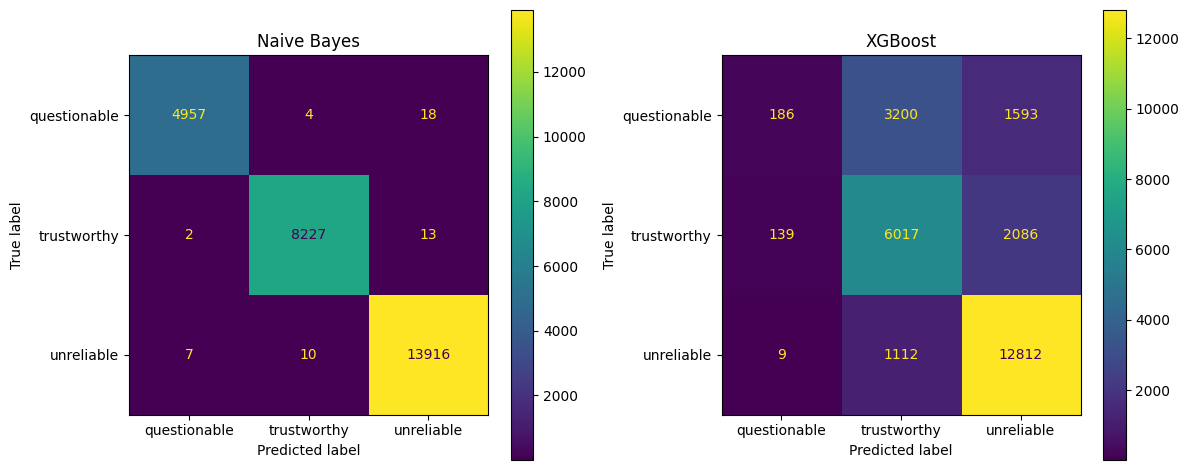

In [30]:
plot_confusion_matrices(
    pipeline_nb,
    pipeline_xgb,
    le,
    X_train,
    y_train,
    unrel_proba_train
)

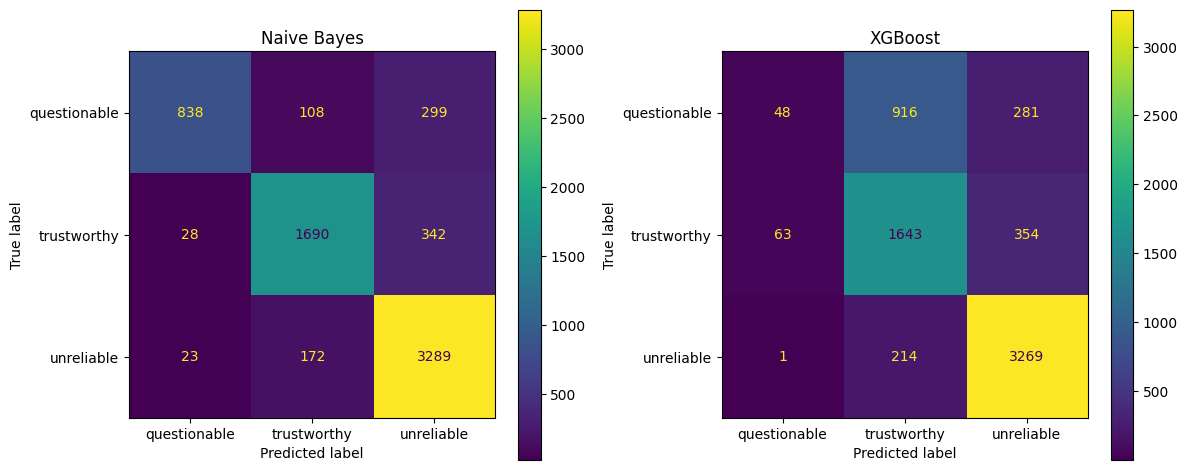

In [31]:
plot_confusion_matrices(
    pipeline_nb,
    pipeline_xgb,
    le,
    X_test,
    y_test,
    unrel_proba_test
)

### Exploring results

In [ ]:
feature_importance = pd.DataFrame({
    "feature": pipeline_A_xg.named_steps["preprocessor"].get_feature_names_out(),
    "importance": pipeline_A_xg.named_steps["classifier"].feature_importances_
})

feature_importance.sort_values("importance", ascending=False).head(20)

NameError: name 'pipeline_A_xg' is not defined

### Removing all speaker context data

In [ ]:
X_extended_ns = X_A.drop(columns=["speaker", "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts"])

X_ns_train, X_ns_test, y_ns_train, y_ns_test = train_test_split(X_extended_ns, y, test_size=0.2)

preprocessor_ns = ColumnTransformer(
    transformers = [
        ("subject", OneHotEncoder(handle_unknown="ignore"), ["subject"]),
        ("context", OneHotEncoder(handle_unknown="ignore"), ["context"]),
        ("job_title", OneHotEncoder(handle_unknown="ignore"), ["job_title"]),
        ("state", OneHotEncoder(handle_unknown="ignore"), ["state"]),
        ("party", OneHotEncoder(handle_unknown="ignore"), ["party"]),
        ("unrel_proba", "passthrough", ["unrel_proba"])
    ]
)

pipeline_ns_xg = Pipeline([
    ("preprocessor", preprocessor_ns),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

y_ns_train_e = le.fit_transform(y_ns_train)
y_ns_test_e = le.transform(y_ns_test)

#X_A_train_sparse = X_A_train
pipeline_ns_xg.fit(X_ns_train, y_ns_train_e)

cv_results_ns_xg = cross_validate(pipeline_ns_xg, X_ns_train, y_ns_train_e, cv=5, scoring='accuracy')


In [ ]:
print("XGBoost mean Accuracy with no speaker information: ", cv_results_ns_xg["test_score"].mean())

XGBoost mean Accuracy with no speaker information:  0.7876188364118001


### Removing all Statement data & Speaker context data

In [ ]:
speaker_data = ["speaker", "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts"]
speaker_data_nb = ["speaker", "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts", "unrel_proba"]


X_extended_nss = X_A.drop(columns=["speaker", "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts", "unrel_proba"])

X_nss_train, X_nss_test, y_nss_train, y_nss_test = train_test_split(X_extended_nss, y, test_size=0.2)

preprocessor_nss = ColumnTransformer(
    transformers = [
        ("subject", OneHotEncoder(handle_unknown="ignore"), ["subject"]),
        ("context", OneHotEncoder(handle_unknown="ignore"), ["context"]),
        ("job_title", OneHotEncoder(handle_unknown="ignore"), ["job_title"]),
        ("state", OneHotEncoder(handle_unknown="ignore"), ["state"]),
        ("party", OneHotEncoder(handle_unknown="ignore"), ["party"])
    ]
)

In [ ]:
pipeline_nss_xg = Pipeline([
    ("preprocessor", preprocessor_nss),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

y_nss_train_e = le.fit_transform(y_nss_train)
y_nss_test_e = le.transform(y_nss_test)

#X_A_train_sparse = X_A_train
pipeline_nss_xg.fit(X_nss_train, y_nss_train_e)

cv_results_nss_xg = cross_validate(pipeline_nss_xg, X_nss_train, y_nss_train_e, cv=5, scoring='accuracy')

In [ ]:
print("XGBoost mean Accuracy with no speaker or statement information: ", cv_results_nss_xg["test_score"].mean())

XGBoost mean Accuracy with no speaker or statement information:  0.5244164171781056


# Sensitivity Analysis

We have run several scenarios in order to understand where the model's capacity to predict the categories comes from. Those scenarios consist in:

- Naive Bayes Model alone (considering all features). **Accuracy = 54%**
- XGBoost (+ 'unrel_proba' from NB, - 'statement'). **Accuracy = 81%**
- XGBoost (+ 'unrel_proba' from NB, - 'statement' & all speaker data). **Accuracy = 79%**
- XGBoost (- 'statement' & speaker data & 'unrel_proba' from NB). **Accuracy = 54%**

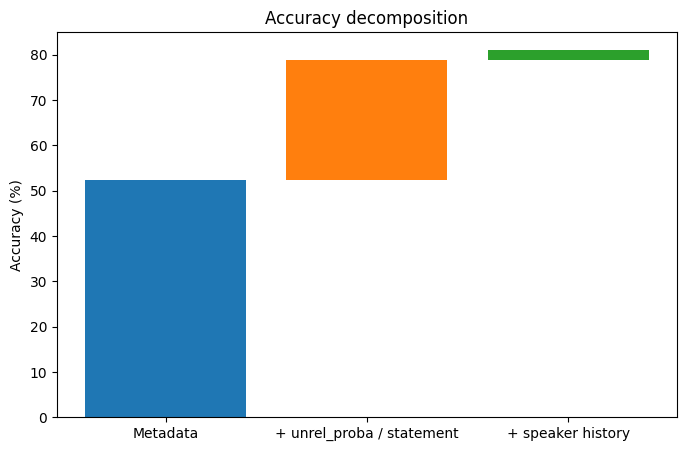

In [ ]:
start = cv_results_nss_xg["test_score"].mean() * 100
add1 = (cv_results_ns_xg["test_score"].mean() - cv_results_nss_xg["test_score"].mean()) * 100
add2 = (cv_results_A_xg["test_score"].mean() - cv_results_ns_xg["test_score"].mean()) * 100

plt.figure(figsize=(8,5))

plt.bar("Metadata", start)
plt.bar("+ unrel_proba / statement", add1, bottom=start)
plt.bar("+ speaker history", add2, bottom=start+add1)

plt.ylabel("Accuracy (%)")
plt.title("Accuracy decomposition")
plt.show()

In [ ]:
speaker_data = ["speaker", "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts"]
speaker_data_nb = ["speaker", "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts", "unrel_proba"]

meta_columns = X_A.drop(columns=speaker_data_nb).columns.tolist()

In [ ]:
dropped_col_acc = {}

for col in meta_columns:
    X_extended_ns = X_A.drop(columns=["speaker", "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts", "unrel_proba", col])

    X_ns_train, X_ns_test, y_ns_train, y_ns_test = train_test_split(X_extended_ns, y, test_size=0.2)

    transformers = []

    if "subject" in X_extended_ns.columns:
        transformers.append(("subject", OneHotEncoder(handle_unknown="ignore"), ["subject"]))
    if "context" in X_extended_ns.columns:
        transformers.append(("context", OneHotEncoder(handle_unknown="ignore"), ["context"]))
    if "job_title" in X_extended_ns.columns:
        transformers.append(("job_title", OneHotEncoder(handle_unknown="ignore"), ["job_title"]))
    if "state" in X_extended_ns.columns:
        transformers.append(("state", OneHotEncoder(handle_unknown="ignore"), ["state"]))
    if "party" in X_extended_ns.columns:
        transformers.append(("party", OneHotEncoder(handle_unknown="ignore"), ["party"]))


    preprocessor_ns = ColumnTransformer(
        transformers=transformers
    )

    pipeline_ns_xg = Pipeline([
        ("preprocessor", preprocessor_ns),
        ("classifier", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ))
    ])

    y_ns_train_e = le.fit_transform(y_ns_train)
    y_ns_test_e = le.transform(y_ns_test)

    #X_A_train_sparse = X_A_train
    pipeline_ns_xg.fit(X_ns_train, y_ns_train_e)

    cv_results_ns_xg = cross_validate(pipeline_ns_xg, X_ns_train, y_ns_train_e, cv=5, scoring='accuracy')

    dropped_col_acc[col] = cv_results_ns_xg["test_score"].mean()


print("The contribution of each metadata column on the prediction score is:")
dropped_col_acc

The contribution of each metadata column on the prediction score is:


{'subject': 0.525447358507009,
 'job_title': 0.5240848779922096,
 'state': 0.5199970498804184,
 'party': 0.5169036562154442,
 'context': 0.5264416708799122}

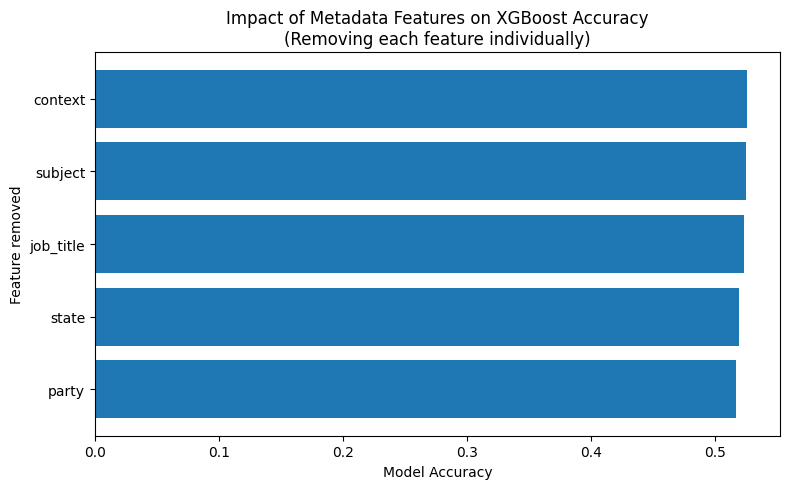

In [ ]:
# Convert dictionary to DataFrame
importance_df = pd.DataFrame(
    dropped_col_acc.items(),
    columns=["Feature", "Accuracy Gain"]
)

# Sort by importance
importance_df = importance_df.sort_values(
    by="Accuracy Gain",
    ascending=True
)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["Feature"],
    importance_df["Accuracy Gain"]
)

plt.xlabel("Model Accuracy")
plt.ylabel("Feature removed")
plt.title("Impact of Metadata Features on XGBoost Accuracy\n(Removing each feature individually)")
plt.tight_layout()

plt.show()

## Random predictions